#Anemia Detection

**Mounting File**

In [3]:
from google.colab import files
uploaded = files.upload()

ModuleNotFoundError: No module named 'google.colab'

**Importing Libraries**

In [55]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Model
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Save model
import pickle

**Columns And Files**

In [56]:
df = pd.read_csv("anemia_enhanced_dataseet (1).csv")

df.head()

,Gender,Hemoglobin,MCH,MCHC,MCV,Result,Diet_Type,Fatigue,Menstrual_Status,Anemia_Risk_Level
0,Male,14.9,22.7,29.1,83.7,0,Veg,No,No,Low
1,Female,15.9,25.4,28.3,72.0,0,Non-Veg,No,Yes,Low
2,Female,9.0,21.5,29.6,71.2,1,Veg,Yes,Yes,High
3,Female,14.9,16.0,31.4,87.5,0,Non-Veg,No,Yes,Low
4,Male,14.7,22.0,28.2,99.5,0,Veg,No,No,Low


**Describing Columns**

In [57]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1421 entries, 0 to 1420
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             1421 non-null   object 
 1   Hemoglobin         1421 non-null   float64
 2   MCH                1421 non-null   float64
 3   MCHC               1421 non-null   float64
 4   MCV                1421 non-null   float64
 5   Result             1421 non-null   int64  
 6   Diet_Type          1421 non-null   object 
 7   Fatigue            1421 non-null   object 
 8   Menstrual_Status   1421 non-null   object 
 9   Anemia_Risk_Level  1421 non-null   object 
dtypes: float64(4), int64(1), object(5)
memory usage: 111.1+ KB


,0
Gender,0
Hemoglobin,0
MCH,0
MCHC,0
MCV,0
Result,0
Diet_Type,0
Fatigue,0
Menstrual_Status,0
Anemia_Risk_Level,0


**Checking Target Distribution**

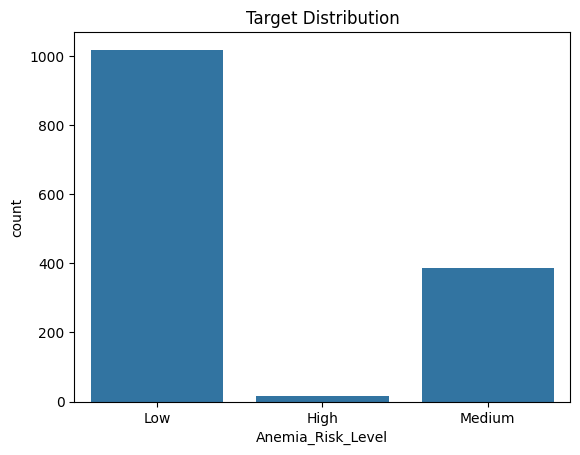

In [58]:
sns.countplot(x='Anemia_Risk_Level', data=df)
plt.title("Target Distribution")
plt.show()

**Pre Processing**

In [59]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_cols = ['Gender', 'Diet_Type', 'Fatigue', 'Menstrual_Status', 'Result']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Encode target separately
target_encoder = LabelEncoder()
df['Anemia_Risk_Level'] = target_encoder.fit_transform(df['Anemia_Risk_Level'])

# Save target encoder too
label_encoders['Anemia_Risk_Level'] = target_encoder

In [60]:
print(df.columns)

Index(['Gender', 'Hemoglobin', 'MCH', 'MCHC', 'MCV', 'Result', 'Diet_Type',
       'Fatigue', 'Menstrual_Status', 'Anemia_Risk_Level'],
      dtype='object')


In [61]:
le_dict = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

**Target Split/ Feature Split**

In [62]:
X = df.drop('Anemia_Risk_Level', axis=1)
y = df['Anemia_Risk_Level']


**Train Test Split**

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Train XGBoost Model**

In [64]:
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [82]:
def preprocess_input(input_data):
    import pandas as pd

    df = pd.DataFrame([input_data])

    categorical_cols = ['Gender', 'Diet_Type', 'Fatigue', 'Menstrual_Status', 'Result']

    for col in categorical_cols:
        if col in le_dict:
            df[col] = le_dict[col].transform(df[col])

    return df

**Evaluation**

In [65]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00       204
           2       1.00      1.00      1.00        78

    accuracy                           1.00       285
   macro avg       1.00      1.00      1.00       285
weighted avg       1.00      1.00      1.00       285



**Confusion Matrix**

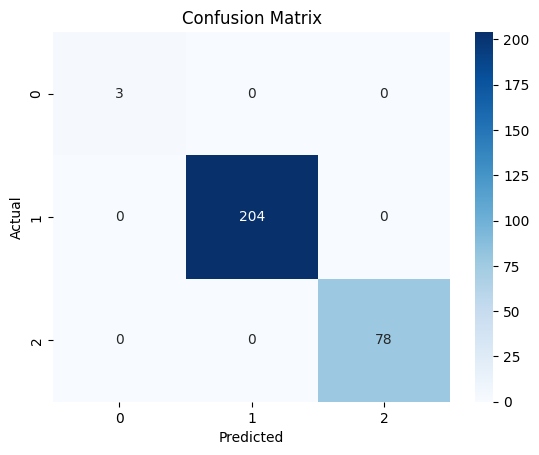

In [66]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Feature Importance**

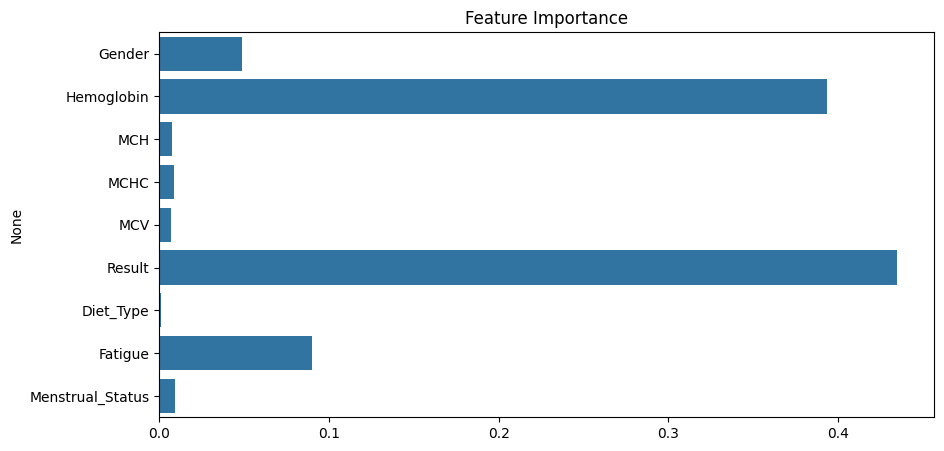

In [67]:
importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(10,5))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()

**Save Models + Encoders**

In [68]:
# Save model
with open("xgboost_anemia_model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save encoders
with open("label_encoders.pkl", "wb") as f:
    pickle.dump(le_dict, f)

#Installing Xgboost shap imbalanced-learn

**Imports**

In [69]:
from sklearn.model_selection import RandomizedSearchCV
from imblearn.over_sampling import SMOTE
import shap

**Applying SMOTE**

In [70]:
smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_sm).value_counts())

Before SMOTE: Anemia_Risk_Level
1    815
2    308
0     13
Name: count, dtype: int64
After SMOTE: Anemia_Risk_Level
1    815
2    815
0    815
Name: count, dtype: int64


**RandomizedSearchCV**

In [71]:
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'min_child_weight': [1, 3, 5]
}

In [72]:
xgb = XGBClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,           # fast + effective
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_sm, y_train_sm)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'gamma': [0, 0.1, 0.2],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300, 400],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, verbose=2)

**Best Model**

In [73]:
print("Best Params:", random_search.best_params_)

best_model = random_search.best_estimator_

Best Params: {'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.7}


**Evaluation**

In [74]:
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00       204
           2       1.00      1.00      1.00        78

    accuracy                           1.00       285
   macro avg       1.00      1.00      1.00       285
weighted avg       1.00      1.00      1.00       285



**SHAP For Explainability**

In [75]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

**SHAP Summary Plot**

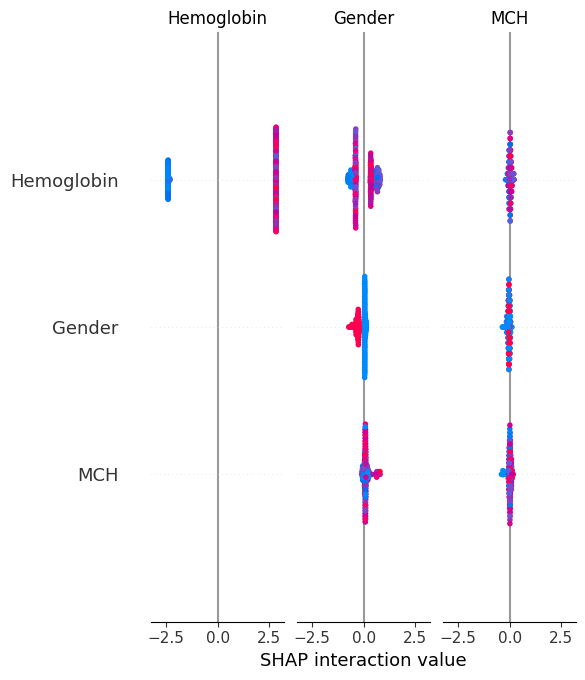

In [76]:
shap.summary_plot(shap_values, X_test)

**Single Prediction Explanation**

In [77]:
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(285, 9, 3)


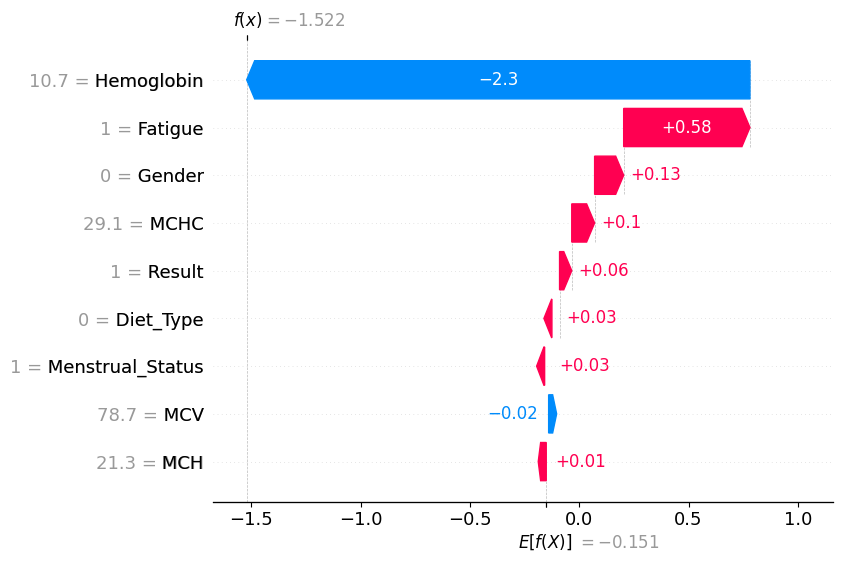

In [78]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0][:, 0],
        base_values=explainer.expected_value[0],
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)

**Saving Final Model**

In [79]:
with open("xgboost_final_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

In [80]:
import pickle

# Save trained model
pickle.dump(best_model, open("xgboost_final_model.pkl", "wb"))

# Save label encoders
pickle.dump(label_encoders, open("label_encoders.pkl", "wb"))

In [81]:
from google.colab import files

files.download("xgboost_final_model.pkl")
files.download("label_encoders.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>